In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import *
from MODELS.Models import *
from MODELS.teamInfo import *


In [2]:
modelPTS = joblib.load('../MODELS/Models/xgbPTSModelNoOppStats.pkl')
featuresPTS = joblib.load('../MODELS/Models/topPTSfeaturesNoOppStats.pkl')
modelREB = joblib.load('../MODELS/Models/xgbREBModelNoOppStats.pkl')
featuresREB = joblib.load('../MODELS/Models/topREBfeaturesNoOppStats.pkl')

In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25_reb = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_25.csv')
s24_reb = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_24.csv')

dfPTS = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')
dfREB = pd.concat([s25_reb, s24_reb]).sort_values(by='GAME_DATE')
date = '2024-11-30'

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
trailRun = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points') & (backtestData['GAME_DATE'] == date)]
trailRun

C:\Users\alexg\AppData\Local\Temp\ipykernel_26532\3569531037.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
20790,20790,20790,20790,Trae Young,player_points,underdog,over,22.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,over
20791,20791,20791,20791,Trae Young,player_points,underdog,under,22.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20792,20792,20792,20792,Brandon Miller,player_points,underdog,under,26.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20793,20793,20793,20793,Bogdan Bogdanovic,player_points,underdog,over,11.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,over
20794,20794,20794,20794,Bogdan Bogdanovic,player_points,underdog,under,11.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21086,21086,21086,21086,Daniel Gafford,player_points,underdog,over,10.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over
21087,21087,21087,21087,Lauri Markkanen,player_points,underdog,under,21.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,under
21088,21088,21088,21088,Brice Sensabaugh,player_points,underdog,over,8.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over
21089,21089,21089,21089,Daniel Gafford,player_points,underdog,under,10.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,under


In [6]:
results = backtestPairs(dfPTS, backtestData, date, modelPTS, featuresPTS, edge_threshold=4.5, top_n=10, simulations=10000, stat_col='PTS')
results

Processing pairs...


,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,min_edge,date
0,Alex Sarr,Brice Sensabaugh,OVER,OVER,10.5,8.5,17.58,15.77,13,13,7.08,7.27,1,1,1,1,1.708,0.9025,7.08,2024-11-30
1,Brice Sensabaugh,Cody Martin,OVER,UNDER,8.5,9.5,15.77,3.09,13,9,7.27,-6.41,1,1,1,1,1.708,0.9025,6.41,2024-11-30
2,Alex Sarr,Cody Martin,OVER,UNDER,10.5,9.5,17.58,3.09,13,9,7.08,-6.41,1,1,1,1,1.708,0.9025,6.41,2024-11-30
3,Cody Martin,Collin Sexton,UNDER,OVER,9.5,18.5,3.09,23.24,9,26,-6.41,4.74,1,1,1,1,1.428,0.8093,4.74,2024-11-30
4,Alex Sarr,Collin Sexton,OVER,OVER,10.5,18.5,17.58,23.24,13,26,7.08,4.74,1,1,1,1,1.428,0.8093,4.74,2024-11-30
5,Collin Sexton,P.J. Washington,OVER,OVER,18.5,15.5,23.24,20.09,26,19,4.74,4.59,1,1,1,1,0.811,0.6036,4.59,2024-11-30
6,Cody Martin,P.J. Washington,UNDER,OVER,9.5,15.5,3.09,20.09,9,19,-6.41,4.59,1,1,1,1,1.019,0.6731,4.59,2024-11-30
7,Alex Sarr,P.J. Washington,OVER,OVER,10.5,15.5,17.58,20.09,13,19,7.08,4.59,1,1,1,1,1.019,0.6731,4.59,2024-11-30
8,Brice Sensabaugh,P.J. Washington,OVER,OVER,8.5,15.5,15.77,20.09,13,19,7.27,4.59,1,1,1,1,1.019,0.6731,4.59,2024-11-30
9,Collin Sexton,Damian Lillard,OVER,OVER,18.5,24.5,23.24,29.02,26,37,4.74,4.52,1,1,1,1,0.801,0.6004,4.52,2024-11-30


In [ ]:
# results = backtestPairs(dfREB, backtestData, date, modelREB, featuresREB, edge_threshold=2.0, top_n=15, simulations=10000, stat_col='REB')
# results

Processing pairs...


,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,date
0,Isaiah Collier,Quentin Grimes,OVER,OVER,1.5,3.5,3.14,5.21,0,7,1.64,1.71,0,1,0,0,0.925,0.6416,2024-11-30
1,Caleb Martin,Quentin Grimes,UNDER,OVER,4.5,3.5,3.53,5.21,3,7,-0.97,1.71,1,1,0,1,0.661,0.5538,2024-11-30
2,Onyeka Okongwu,Quentin Grimes,OVER,OVER,6.5,3.5,8.38,5.21,7,7,1.88,1.71,1,1,0,1,0.658,0.5527,2024-11-30
3,Jalen Johnson,Quentin Grimes,OVER,OVER,9.5,3.5,10.80,5.21,9,7,1.30,1.71,0,1,0,0,0.655,0.5517,2024-11-30
4,Caleb Martin,Isaiah Collier,UNDER,OVER,4.5,1.5,3.53,3.14,3,0,-0.97,1.64,1,0,0,0,0.637,0.5455,2024-11-30
5,Draymond Green,Quentin Grimes,OVER,OVER,6.5,3.5,7.63,5.21,14,7,1.13,1.71,1,1,0,1,0.637,0.5455,2024-11-30
6,Isaiah Collier,Onyeka Okongwu,OVER,OVER,1.5,6.5,3.14,8.38,0,7,1.64,1.88,0,1,0,0,0.633,0.5445,2024-11-30
7,Isaiah Collier,Jalen Johnson,OVER,OVER,1.5,9.5,3.14,10.80,0,9,1.64,1.30,0,0,0,0,0.630,0.5435,2024-11-30
8,Draymond Green,Isaiah Collier,OVER,OVER,6.5,1.5,7.63,3.14,14,0,1.13,1.64,1,0,0,0,0.612,0.5374,2024-11-30
9,Kyshawn George,Quentin Grimes,UNDER,OVER,4.5,3.5,3.75,5.21,4,7,-0.75,1.71,1,1,0,1,0.512,0.5041,2024-11-30


In [7]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 10, Win Rate: 100.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 10, Wins: 10, Win Rate: 100.00%


## Points

In [8]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(dfPTS, backtestData, date, modelPTS, featuresPTS, edge_threshold=4.5, top_n=10, simulations=10000, stat_col='PTS')
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-06... 14/162
Processing pair

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,409
   Wins: 729
   Hit Rate: 51.74%
   Total Profit: $3,890.00
   Total Staked: $7,045.00
   ROI: 55.22%
   Volatility: $46.06
   Max Drawdown: $-90.00
   Sharpe Ratio: 7.113

 RECOMMENDED BETS ANALYSIS (Edge > 4.5):
   Total Bets: 1,182
   Wins: 654
   Hit Rate: 55.33%
   Total Profit: $3,900.00
   Total Staked: $5,910.00
   ROI: 65.99%
   Volatility: $44.86
   Max Drawdown: $-70.00
   Sharpe Ratio: 7.624


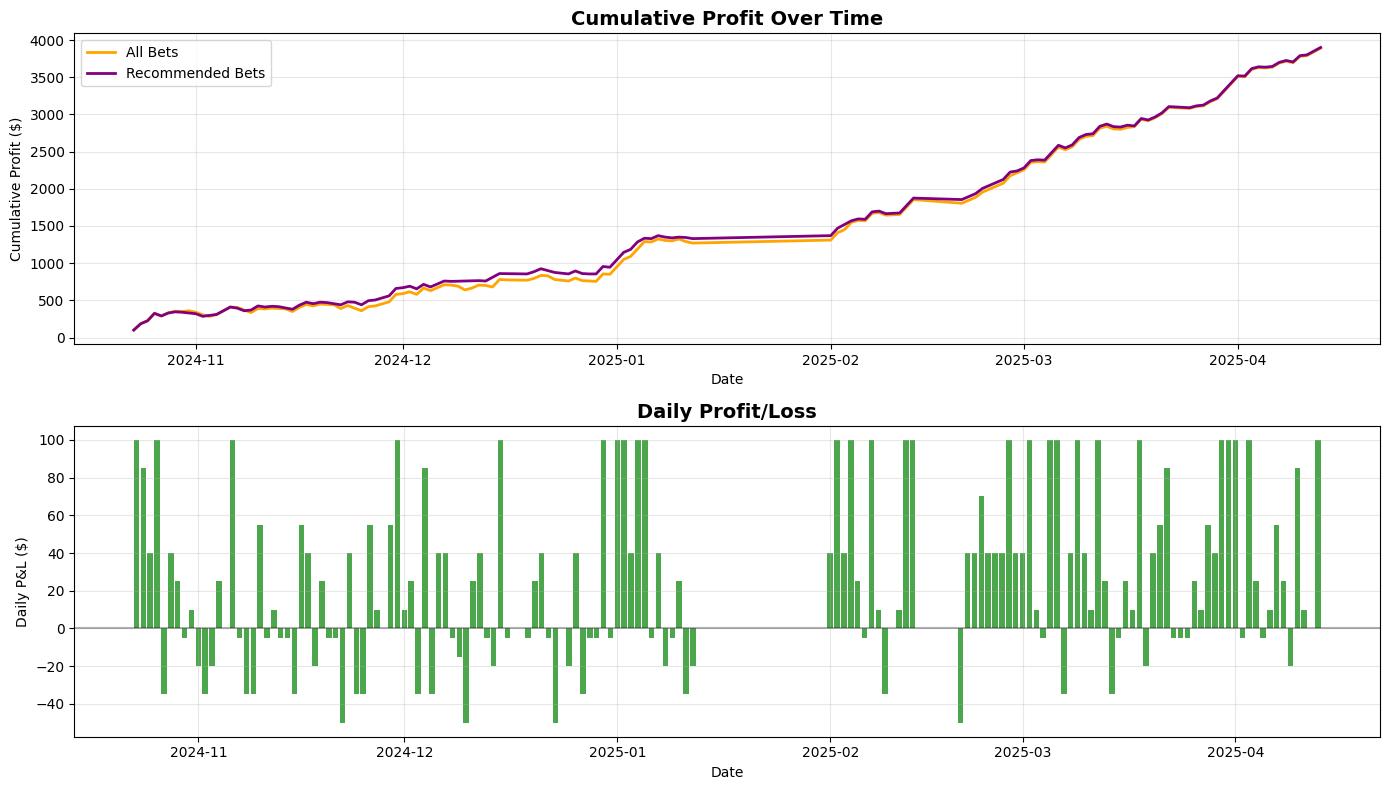

In [9]:
edge = 4.5
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()